# Decision trees and random forests

This notebook completes the **Decision trees and random forests** assignment using the Phishing Websites dataset from the [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/327/phishing+websites).

## Part 1: Decision tree

Initial goal is to construct a small yet useful decision tree that predicts whether a website is a phishing site or not.

An image of the final decision tree.


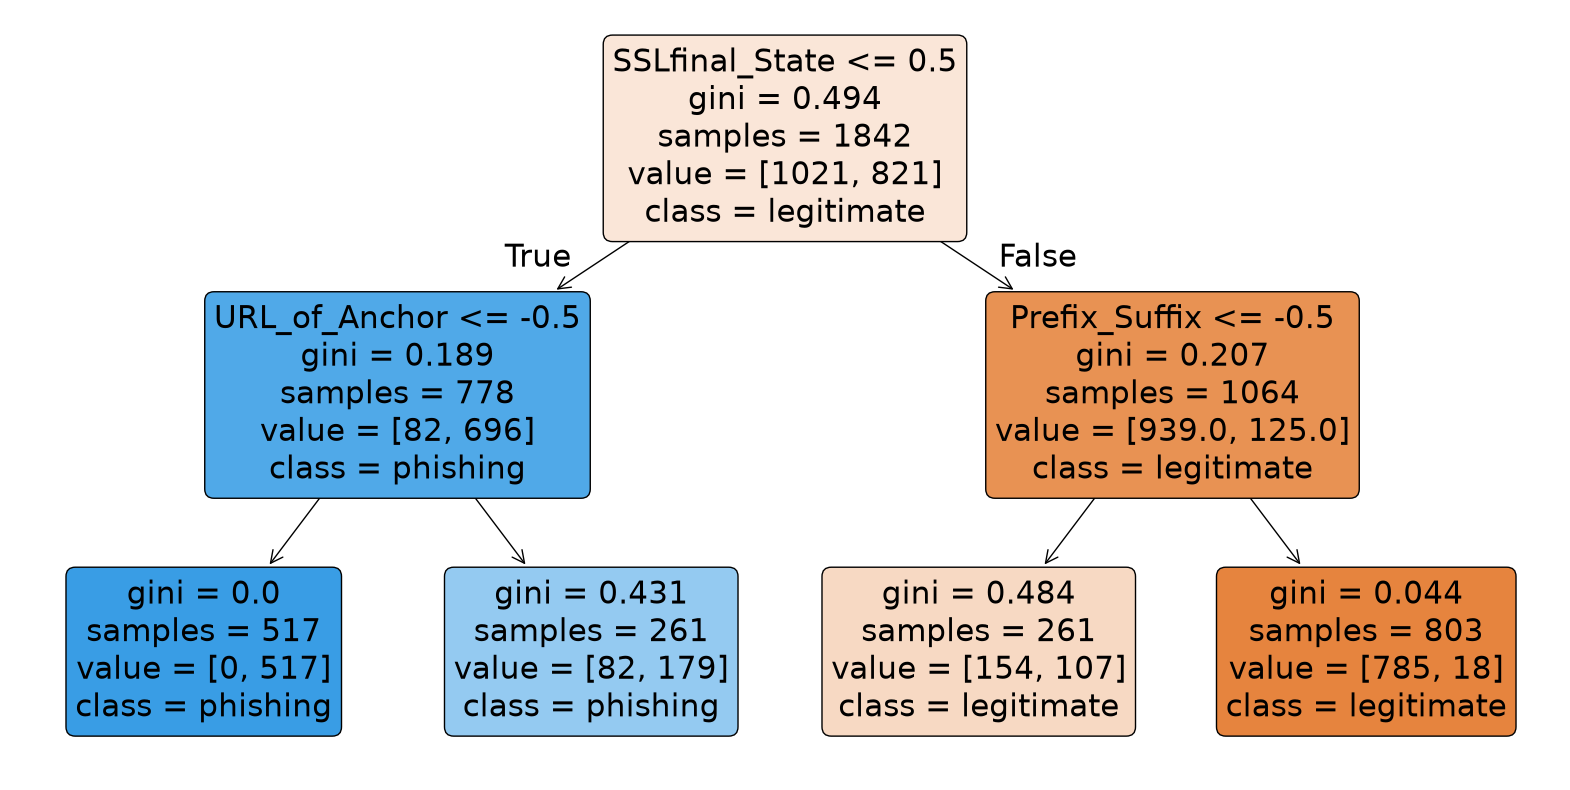

Evaluation metrics for the decision tree.


array([[311,  30],
       [ 41, 232]])

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree  
from sklearn.metrics import confusion_matrix

df = pd.read_csv('data/phishing_websites.csv')

# Converter for 1 and -1
df = df.apply(lambda col: col.str.extract(r"(-?\d+)")[0].astype(int))

X = df.drop(columns="Result") # input features
y = df["Result"]  # target features
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = DecisionTreeClassifier(max_depth=2, random_state=42)
model.fit(X_train, y_train)

print("An image of the final decision tree.")
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=["legitimate", "phishing"], filled=True, rounded=True)
plt.show()

print("Evaluation metrics for the decision tree.")
preds = model.predict(X_test)

confusion_matrix(y_test, preds)

#### Instructions
If SSLfinal_State is low or suspicious, classify the website as phishing. If SSLfinal_State is strong, classify it as legitimate. In this fitted tree, that feature alone determines the final decision; the next checks are present in the tree structure but do not change the outcome.

**If SSLfinal_State <= 0.5:**
* Check URL_of_Anchor.
* If URL_of_Anchor <= -0.5, classify as phishing.
* If URL_of_Anchor > -0.5, classify as phishing.

**If SSLfinal_State > 0.5:**
* Check Prefix_Suffix.
* If Prefix_Suffix <= -0.5, classify as legitimate.
* If Prefix_Suffix > -0.5, classify as legitimate.
